In [1]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Configuration pour les visualisations
plt.style.use('seaborn-v0_8')
sns.set(font_scale=1.2)

# Préparation du dataset

In [2]:

print(" Importation du dataset")

df = pd.read_csv("teleCust.csv")
print(f"Dataset importé avec succès: {df.shape[0]} lignes et {df.shape[1]} colonnes.")


 Importation du dataset
Dataset importé avec succès: 1000 lignes et 12 colonnes.


 Vérification des données du dataset

In [3]:
print("\n1.2 Vérification des données du dataset")
print("Informations sur le dataset:")
print(df.info())


1.2 Vérification des données du dataset
Informations sur le dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   region   1000 non-null   int64  
 1   tenure   1000 non-null   int64  
 2   age      1000 non-null   int64  
 3   marital  1000 non-null   int64  
 4   address  1000 non-null   int64  
 5   income   1000 non-null   float64
 6   ed       1000 non-null   int64  
 7   employ   1000 non-null   int64  
 8   retire   1000 non-null   float64
 9   gender   1000 non-null   int64  
 10  reside   1000 non-null   int64  
 11  custcat  1000 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 93.9 KB
None


In [4]:
print("Description statistique des données numériques:")
print(df.describe())

Description statistique des données numériques:
          region       tenure          age      marital      address  \
count  1000.0000  1000.000000  1000.000000  1000.000000  1000.000000   
mean      2.0220    35.526000    41.684000     0.495000    11.551000   
std       0.8162    21.359812    12.558816     0.500225    10.086681   
min       1.0000     1.000000    18.000000     0.000000     0.000000   
25%       1.0000    17.000000    32.000000     0.000000     3.000000   
50%       2.0000    34.000000    40.000000     0.000000     9.000000   
75%       3.0000    54.000000    51.000000     1.000000    18.000000   
max       3.0000    72.000000    77.000000     1.000000    55.000000   

            income           ed       employ       retire       gender  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean     77.535000     2.671000    10.987000     0.047000     0.517000   
std     107.044165     1.222397    10.082087     0.211745     0.499961   
min    

In [5]:
print("Vérification des valeurs manquantes:")
print(df.isnull().sum())

Vérification des valeurs manquantes:
region     0
tenure     0
age        0
marital    0
address    0
income     0
ed         0
employ     0
retire     0
gender     0
reside     0
custcat    0
dtype: int64


In [6]:
print("Aperçu des premières lignes du dataset:")
print(df.head())

Aperçu des premières lignes du dataset:
   region  tenure  age  marital  address  income  ed  employ  retire  gender  \
0       2      13   44        1        9    64.0   4       5     0.0       0   
1       3      11   33        1        7   136.0   5       5     0.0       0   
2       3      68   52        1       24   116.0   1      29     0.0       1   
3       2      33   33        0       12    33.0   2       0     0.0       1   
4       2      23   30        1        9    30.0   1       2     0.0       0   

   reside  custcat  
0       2        1  
1       6        4  
2       2        3  
3       1        1  
4       4        3  


Répartition des classes

 Répartition des classes


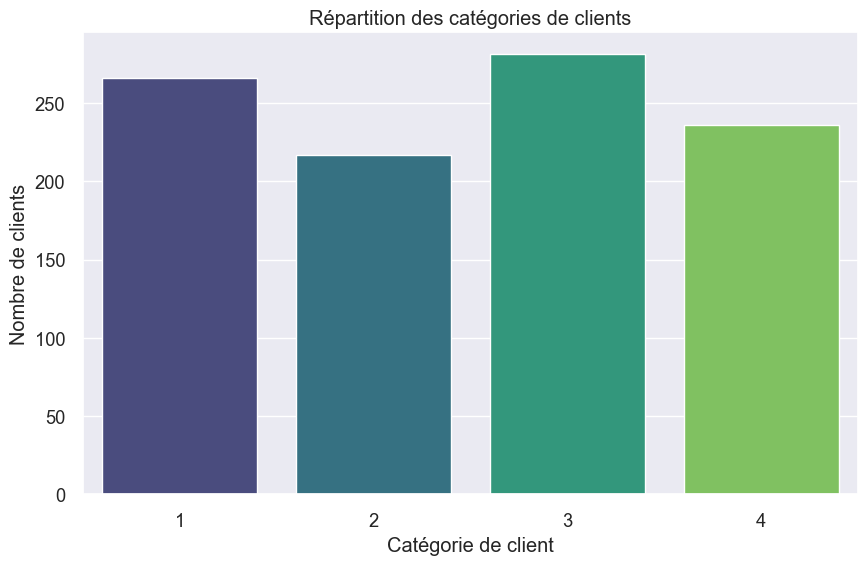

In [7]:
print(" Répartition des classes")
plt.figure(figsize=(10, 6))
sns.countplot(x='custcat', data=df, palette='viridis')
plt.title('Répartition des catégories de clients')
plt.xlabel('Catégorie de client')
plt.ylabel('Nombre de clients')
plt.savefig('repartition_categories_clients.png')
plt.show()
plt.close()

In [8]:
print(f"Répartition des catégories de clients:\n{df['custcat'].value_counts()}")
print(f"Pourcentage par catégorie:")
for cat, count in df['custcat'].value_counts().items():
    print(f"Catégorie {cat}: {count/len(df)*100:.2f}%")

Répartition des catégories de clients:
custcat
3    281
1    266
4    236
2    217
Name: count, dtype: int64
Pourcentage par catégorie:
Catégorie 3: 28.10%
Catégorie 1: 26.60%
Catégorie 4: 23.60%
Catégorie 2: 21.70%


Encoder les variables qualitatives

In [9]:

print(" Encodage des variables qualitatives")
categorical_features = ['region', 'marital', 'gender', 'reside']
numerical_features = ['tenure', 'age', 'address', 'income', 'ed', 'employ', 'retire']

print(f"Variables catégorielles: {categorical_features}")
print(f"Variables numériques: {numerical_features}")

# Préparation du preprocessing
X = df.drop('custcat', axis=1)
y = df['custcat']

# Feature scaling et preprocessing
print(" Feature scaling")
# Création d'un pipeline de prétraitement
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

 Encodage des variables qualitatives
Variables catégorielles: ['region', 'marital', 'gender', 'reside']
Variables numériques: ['tenure', 'age', 'address', 'income', 'ed', 'employ', 'retire']
 Feature scaling



Visualisation de la corrélation entre les features numériques

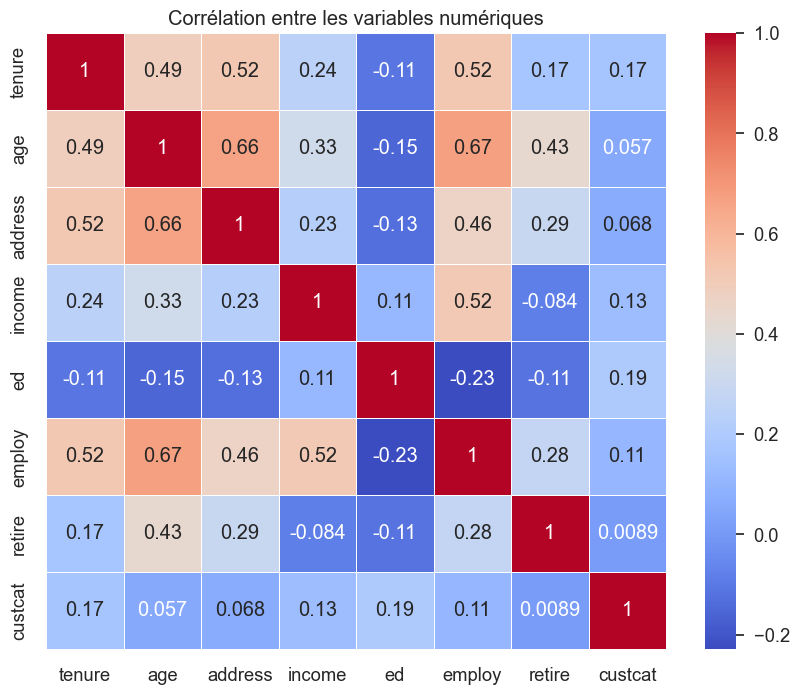

In [10]:

plt.figure(figsize=(10, 8))
correlation_matrix = df[numerical_features + ['custcat']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Corrélation entre les variables numériques')
plt.savefig('correlation_matrix_client.png')
plt.show()  
plt.close()

Distribution des variables numériques

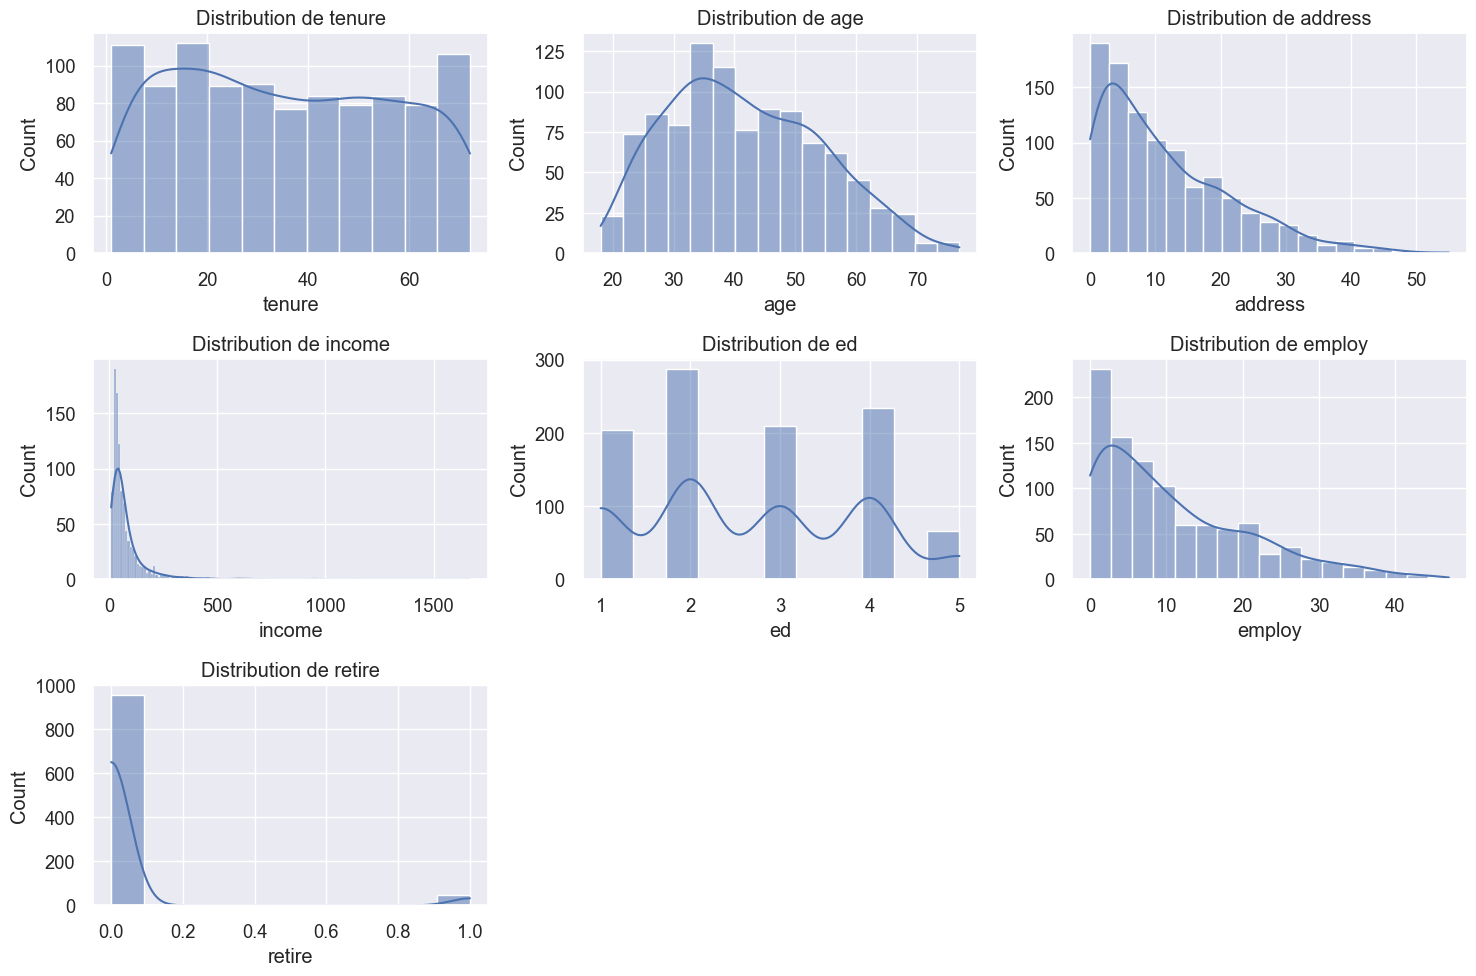

In [11]:
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i+1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution de {feature}')
plt.tight_layout()
plt.savefig('distribution_variables_numeriques.png')
plt.show()
plt.close()

Relations entre variables catégorielles et la cible

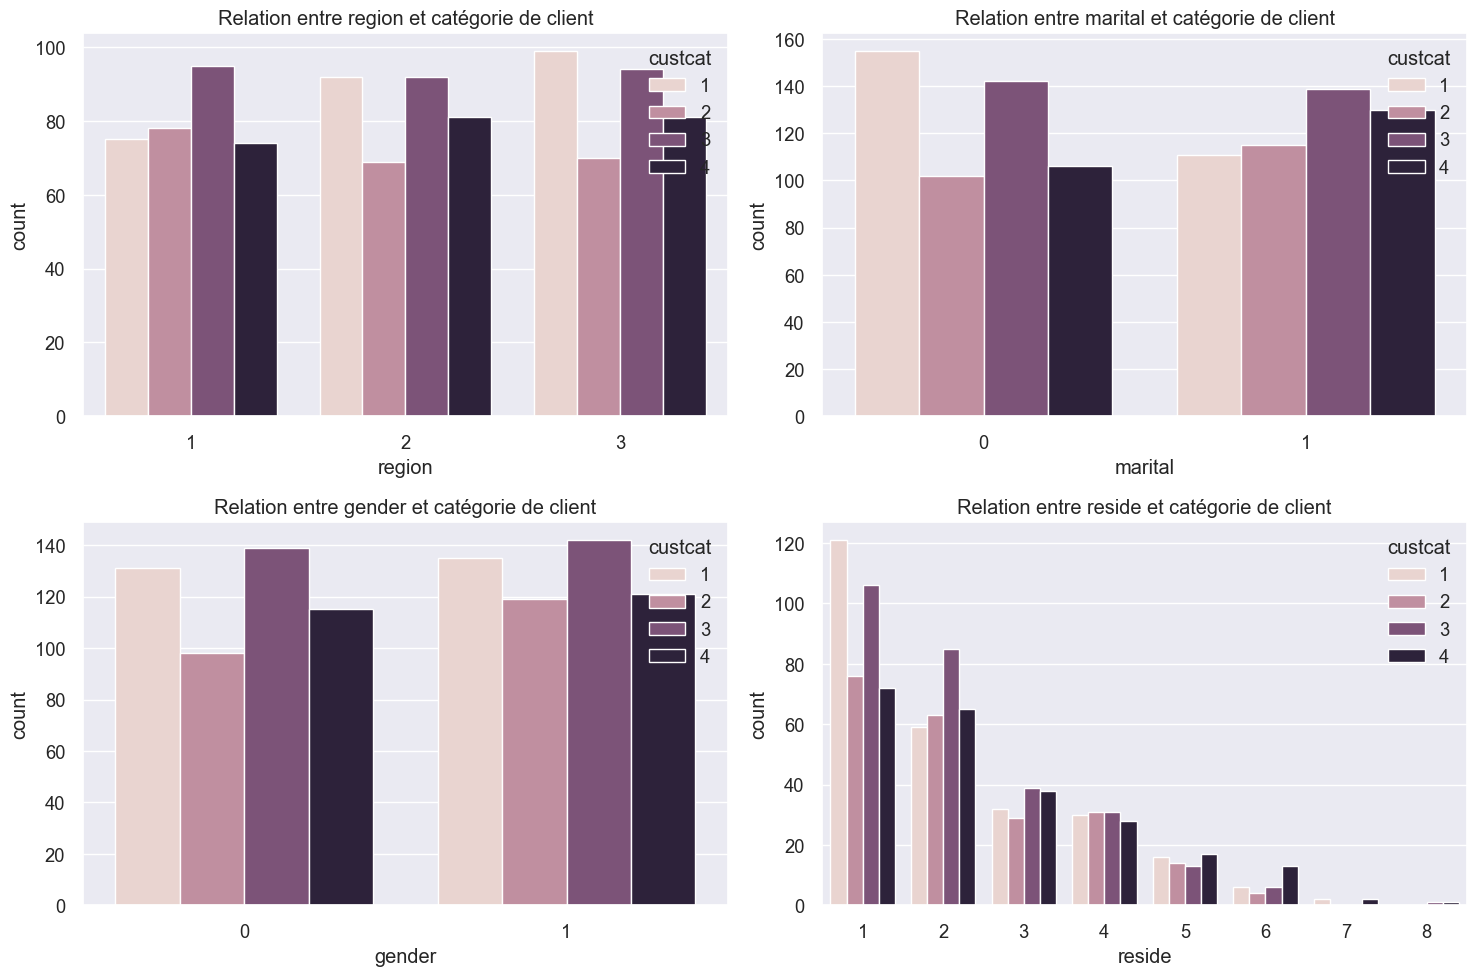

In [12]:
plt.figure(figsize=(15, 10))
for i, feature in enumerate(categorical_features):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=feature, hue='custcat', data=df)
    plt.title(f'Relation entre {feature} et catégorie de client')
plt.tight_layout()
plt.savefig('relation_variables_categorielles_cible.png')
plt.show()
plt.close()

Partitionnement du Dataset

In [13]:
print("Partitionnement du Dataset")
# Séparation en jeux d'entraînement et de test (75% / 25%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print(f"Taille du jeu d'entraînement: {X_train.shape[0]} échantillons")
print(f"Taille du jeu de test: {X_test.shape[0]} échantillons")

Partitionnement du Dataset
Taille du jeu d'entraînement: 750 échantillons
Taille du jeu de test: 250 échantillons


# Apprentissage

In [14]:
# Fonction pour évaluer et afficher les performances d'un modèle
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    # Entraînement
    print(f"\nEntraînement du modèle {name}...")
    model.fit(X_train, y_train)
    
    # Prédictions
    y_pred = model.predict(X_test)
    
    # Évaluation
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')  # weighted pour multi-classe
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    print(f"Performance du modèle {name}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score (weighted): {f1:.4f}")
    print("Matrice de confusion:")
    print(conf_matrix)
    
    # Visualisation de la matrice de confusion
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Prédiction')
    plt.ylabel('Réel')
    plt.title(f'Matrice de confusion - {name}')
    plt.savefig(f'confusion_matrix_client_{name.replace(" ", "_").lower()}.png')
    plt.show()
    plt.close()
    
    # Afficher le rapport de classification complet
    print("\nRapport de classification:")
    print(classification_report(y_test, y_pred))
    
    return accuracy, f1, conf_matrix, model

 K-PPV (k=5)

Classification avec K-PPV (k=5)

Entraînement du modèle K-PPV (k=5)...
Performance du modèle K-PPV (k=5):
Accuracy: 0.3360
F1 Score (weighted): 0.3312
Matrice de confusion:
[[33  7 19  8]
 [16 16 13  9]
 [27 16 20  7]
 [13 22  9 15]]


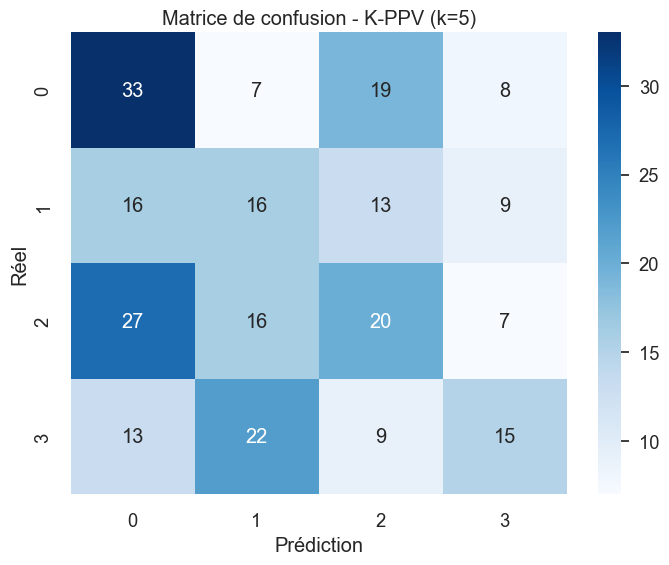


Rapport de classification:
              precision    recall  f1-score   support

           1       0.37      0.49      0.42        67
           2       0.26      0.30      0.28        54
           3       0.33      0.29      0.31        70
           4       0.38      0.25      0.31        59

    accuracy                           0.34       250
   macro avg       0.34      0.33      0.33       250
weighted avg       0.34      0.34      0.33       250



In [15]:

print("Classification avec K-PPV (k=5)")
# Pipeline pour K-PPV avec k=5
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

# Évaluation du modèle K-PPV avec k=5
knn_accuracy, knn_f1, knn_cm, knn_model = evaluate_model("K-PPV (k=5)", knn_pipeline, X_train, X_test, y_train, y_test)

variation de k et analyse des résultats

Variation de k et analyse des résultats pour K-PPV:
Meilleur k trouvé: 8 avec une précision de 0.3760

Entraînement du modèle K-PPV (k=8)...
Performance du modèle K-PPV (k=8):
Accuracy: 0.3760
F1 Score (weighted): 0.3711
Matrice de confusion:
[[32  5 20 10]
 [15 23 10  6]
 [27 12 24  7]
 [ 9 23 12 15]]


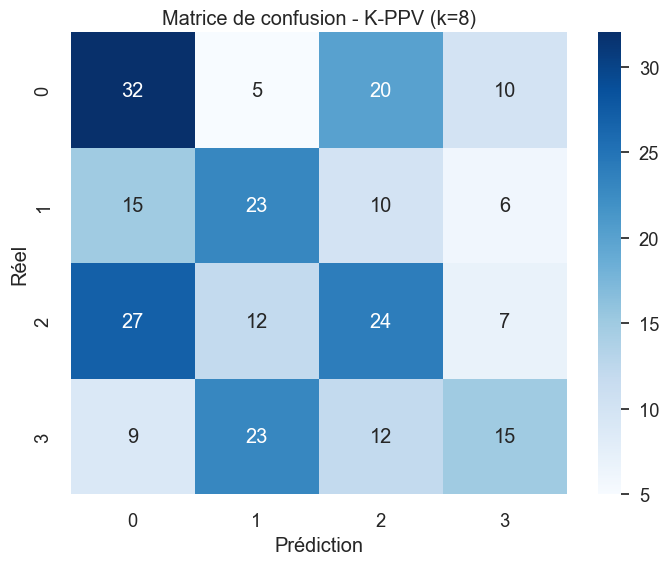


Rapport de classification:
              precision    recall  f1-score   support

           1       0.39      0.48      0.43        67
           2       0.37      0.43      0.39        54
           3       0.36      0.34      0.35        70
           4       0.39      0.25      0.31        59

    accuracy                           0.38       250
   macro avg       0.38      0.38      0.37       250
weighted avg       0.38      0.38      0.37       250



In [16]:
print("Variation de k et analyse des résultats pour K-PPV:")
k_values = list(range(1, 21))
train_scores = []
test_scores = []

for k in k_values:
    knn = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier(n_neighbors=k))
    ])
    knn.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, knn.predict(X_train)))
    test_scores.append(accuracy_score(y_test, knn.predict(X_test)))

# Détermination du meilleur k
best_k = k_values[np.argmax(test_scores)]
print(f"Meilleur k trouvé: {best_k} avec une précision de {max(test_scores):.4f}")

# Réévaluation avec le meilleur k
knn_best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=best_k))
])

knn_best_accuracy, knn_best_f1, knn_best_cm, knn_best_model = evaluate_model(
    f"K-PPV (k={best_k})", knn_best_pipeline, X_train, X_test, y_train, y_test
)

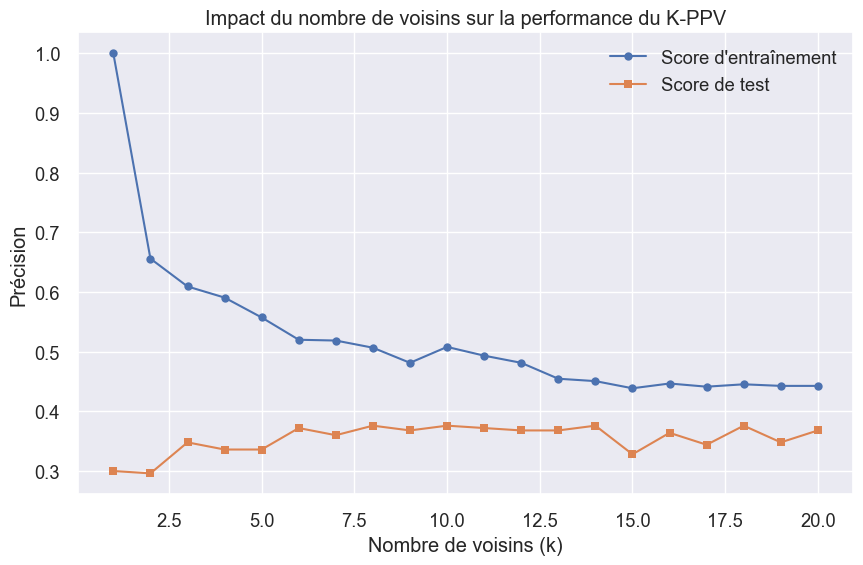

In [17]:

# Visualisation de l'impact de k sur les performances
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, 'o-', label='Score d\'entraînement')
plt.plot(k_values, test_scores, 's-', label='Score de test')
plt.xlabel('Nombre de voisins (k)')
plt.ylabel('Précision')
plt.title('Impact du nombre de voisins sur la performance du K-PPV')
plt.legend()
plt.grid(True)
plt.savefig('knn_k_analysis_client.png')
plt.show()
plt.close()

Multi-Layer Perceptron (MLP)

 Classification avec Multi-Layer Perceptron (MLP)

Entraînement du modèle MLP...
Performance du modèle MLP:
Accuracy: 0.3040
F1 Score (weighted): 0.3030
Matrice de confusion:
[[24  7 18 18]
 [11 14 11 18]
 [20 17 18 15]
 [16 15  8 20]]


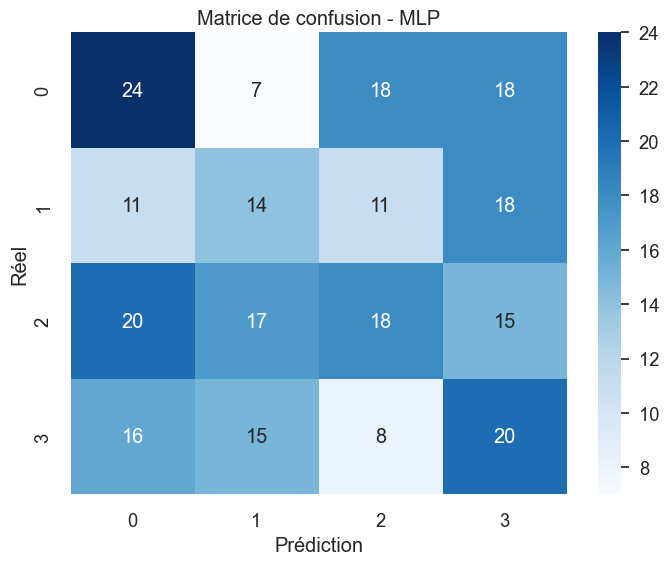


Rapport de classification:
              precision    recall  f1-score   support

           1       0.34      0.36      0.35        67
           2       0.26      0.26      0.26        54
           3       0.33      0.26      0.29        70
           4       0.28      0.34      0.31        59

    accuracy                           0.30       250
   macro avg       0.30      0.30      0.30       250
weighted avg       0.31      0.30      0.30       250


Recherche des meilleurs hyperparamètres pour MLP...
Meilleurs paramètres pour MLP: {'classifier__activation': 'relu', 'classifier__alpha': 0.0001, 'classifier__hidden_layer_sizes': (50,), 'classifier__learning_rate': 'constant'}
Meilleur score F1 (CV): nan

Entraînement du modèle MLP (meilleurs paramètres)...
Performance du modèle MLP (meilleurs paramètres):
Accuracy: 0.3400
F1 Score (weighted): 0.3388
Matrice de confusion:
[[24  9 22 12]
 [10 17  9 18]
 [20 14 20 16]
 [11 12 12 24]]


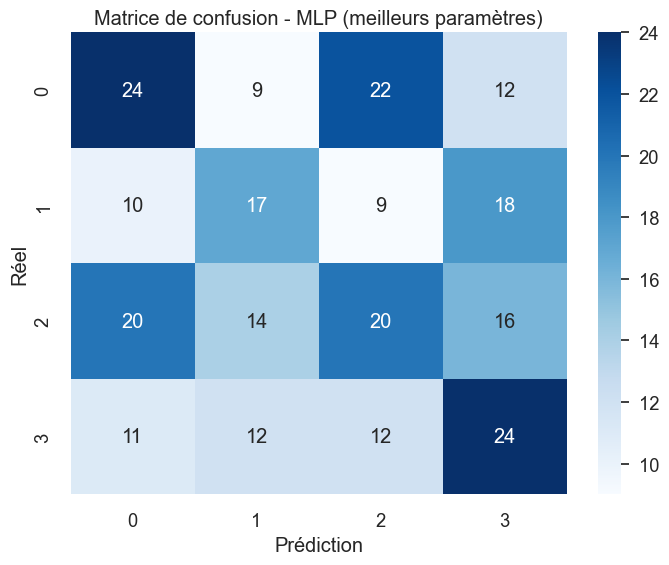


Rapport de classification:
              precision    recall  f1-score   support

           1       0.37      0.36      0.36        67
           2       0.33      0.31      0.32        54
           3       0.32      0.29      0.30        70
           4       0.34      0.41      0.37        59

    accuracy                           0.34       250
   macro avg       0.34      0.34      0.34       250
weighted avg       0.34      0.34      0.34       250



In [18]:

print(" Classification avec Multi-Layer Perceptron (MLP)")
# Pipeline pour MLP avec des paramètres par défaut
mlp_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42))
])

# Évaluation du modèle MLP
mlp_accuracy, mlp_f1, mlp_cm, mlp_model = evaluate_model("MLP", mlp_pipeline, X_train, X_test, y_train, y_test)

# Recherche des meilleurs hyperparamètres pour MLP
print("\nRecherche des meilleurs hyperparamètres pour MLP...")
param_grid_mlp = {
    'classifier__hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'classifier__activation': ['relu', 'tanh'],
    'classifier__alpha': [0.0001, 0.001, 0.01],
    'classifier__learning_rate': ['constant', 'adaptive']
}

grid_search_mlp = GridSearchCV(mlp_pipeline, param_grid_mlp, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_search_mlp.fit(X_train, y_train)

print(f"Meilleurs paramètres pour MLP: {grid_search_mlp.best_params_}")
print(f"Meilleur score F1 (CV): {grid_search_mlp.best_score_:.4f}")

# Réévaluation avec les meilleurs paramètres
mlp_best_accuracy, mlp_best_f1, mlp_best_cm, mlp_best_model = evaluate_model(
    "MLP (meilleurs paramètres)", grid_search_mlp.best_estimator_, X_train, X_test, y_train, y_test
)


 SVM avec différents noyaux

 Classification avec SVM (différents noyaux)

Entraînement SVM avec noyau rbf
Meilleurs paramètres pour SVM avec noyau rbf:
{'classifier__C': 0.1, 'classifier__gamma': 'scale'}
Meilleur score F1 (CV): nan

Entraînement du modèle SVM (rbf)...
Performance du modèle SVM (rbf):
Accuracy: 0.4080
F1 Score (weighted): 0.3592
Matrice de confusion:
[[27  1 24 15]
 [11  0 25 18]
 [16  1 46  7]
 [ 7  3 20 29]]


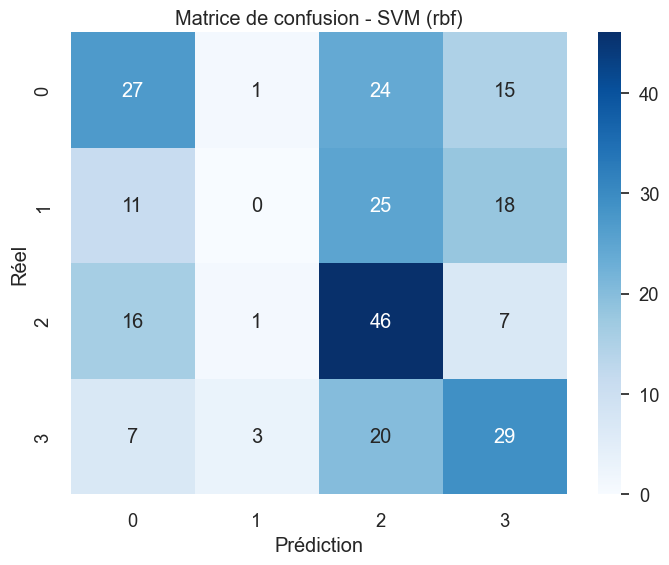


Rapport de classification:
              precision    recall  f1-score   support

           1       0.44      0.40      0.42        67
           2       0.00      0.00      0.00        54
           3       0.40      0.66      0.50        70
           4       0.42      0.49      0.45        59

    accuracy                           0.41       250
   macro avg       0.32      0.39      0.34       250
weighted avg       0.33      0.41      0.36       250


Entraînement SVM avec noyau poly
Meilleurs paramètres pour SVM avec noyau poly:
{'classifier__C': 0.1, 'classifier__degree': 2, 'classifier__gamma': 'scale'}
Meilleur score F1 (CV): nan

Entraînement du modèle SVM (poly)...
Performance du modèle SVM (poly):
Accuracy: 0.3520
F1 Score (weighted): 0.2850
Matrice de confusion:
[[53  0 11  3]
 [34  0 15  5]
 [43  0 26  1]
 [39  0 11  9]]


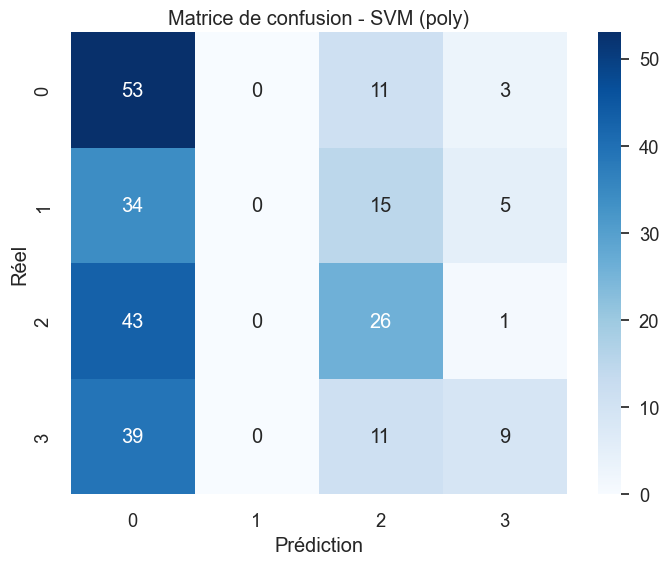


Rapport de classification:
              precision    recall  f1-score   support

           1       0.31      0.79      0.45        67
           2       0.00      0.00      0.00        54
           3       0.41      0.37      0.39        70
           4       0.50      0.15      0.23        59

    accuracy                           0.35       250
   macro avg       0.31      0.33      0.27       250
weighted avg       0.32      0.35      0.29       250


Entraînement SVM avec noyau sigmoid
Meilleurs paramètres pour SVM avec noyau sigmoid:
{'classifier__C': 0.1, 'classifier__gamma': 'scale'}
Meilleur score F1 (CV): nan

Entraînement du modèle SVM (sigmoid)...
Performance du modèle SVM (sigmoid):
Accuracy: 0.3960
F1 Score (weighted): 0.3779
Matrice de confusion:
[[32  1 21 13]
 [12  6 16 20]
 [22  5 35  8]
 [11 10 12 26]]


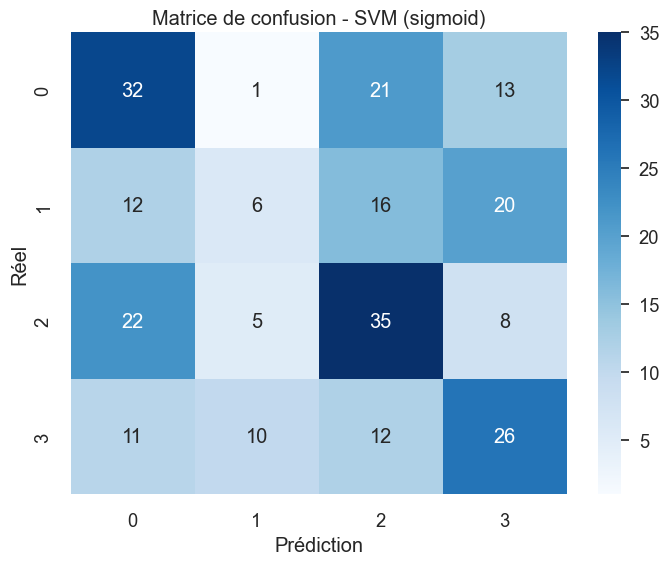


Rapport de classification:
              precision    recall  f1-score   support

           1       0.42      0.48      0.44        67
           2       0.27      0.11      0.16        54
           3       0.42      0.50      0.45        70
           4       0.39      0.44      0.41        59

    accuracy                           0.40       250
   macro avg       0.37      0.38      0.37       250
weighted avg       0.38      0.40      0.38       250


Meilleur noyau SVM: sigmoid
F1 Score: 0.3779
Paramètres: {'classifier__C': 0.1, 'classifier__gamma': 'scale'}


In [19]:
print(" Classification avec SVM (différents noyaux)")

# Pour chaque type de noyau, définir une plage d'hyperparamètres à tester
kernels = ['rbf', 'poly', 'sigmoid']
svm_results = {}

for kernel in kernels:
    print(f"\nEntraînement SVM avec noyau {kernel}")
    
    # Définir les paramètres de recherche pour chaque noyau
    if kernel == 'rbf':
        param_grid = {
            'classifier__C': [0.1, 1, 10, 100],
            'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1]
        }
    elif kernel == 'poly':
        param_grid = {
            'classifier__C': [0.1, 1, 10],
            'classifier__degree': [2, 3, 4],
            'classifier__gamma': ['scale', 'auto', 0.01, 0.1]
        }
    elif kernel == 'sigmoid':
        param_grid = {
            'classifier__C': [0.1, 1, 10],
            'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1]
        }
    
    # Définir le pipeline avec le noyau actuel
    svm_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', SVC(kernel=kernel, random_state=42))
    ])
    
    # Recherche par validation croisée
    grid_search = GridSearchCV(svm_pipeline, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    print(f"Meilleurs paramètres pour SVM avec noyau {kernel}:")
    print(grid_search.best_params_)
    print(f"Meilleur score F1 (CV): {grid_search.best_score_:.4f}")
    
    # Évaluer le modèle avec les meilleurs paramètres
    accuracy, f1, cm, model = evaluate_model(
        f"SVM ({kernel})", grid_search.best_estimator_, X_train, X_test, y_train, y_test
    )
    
    svm_results[kernel] = {
        'accuracy': accuracy,
        'f1': f1,
        'model': model,
        'best_params': grid_search.best_params_
    }

# Déterminer le meilleur noyau SVM
best_kernel = max(svm_results.keys(), key=lambda k: svm_results[k]['f1'])
print(f"\nMeilleur noyau SVM: {best_kernel}")
print(f"F1 Score: {svm_results[best_kernel]['f1']:.4f}")
print(f"Paramètres: {svm_results[best_kernel]['best_params']}")

# Évaluation comparative des performances

In [20]:
# Collecter les résultats de tous les modèles
models_results = {
    f"K-PPV (k={best_k})": {'accuracy': knn_best_accuracy, 'f1': knn_best_f1},
    "MLP (meilleurs params)": {'accuracy': mlp_best_accuracy, 'f1': mlp_best_f1}
}

for kernel in svm_results:
    models_results[f"SVM ({kernel})"] = {
        'accuracy': svm_results[kernel]['accuracy'], 
        'f1': svm_results[kernel]['f1']
    }

# Créer un DataFrame pour la comparaison
comparison_df = pd.DataFrame({
    'Modèle': list(models_results.keys()),
    'Accuracy': [models_results[model]['accuracy'] for model in models_results],
    'F1 Score': [models_results[model]['f1'] for model in models_results]
})

print("Comparaison des performances:")
print(comparison_df)
# Déterminer le meilleur modèle global
best_model_name = max(models_results.keys(), key=lambda k: models_results[k]['f1'])
print(f"\nMeilleur modèle global: {best_model_name}")
print(f"F1 Score: {models_results[best_model_name]['f1']:.4f}")
print(f"Accuracy: {models_results[best_model_name]['accuracy']:.4f}")



Comparaison des performances:
                   Modèle  Accuracy  F1 Score
0             K-PPV (k=8)     0.376  0.371083
1  MLP (meilleurs params)     0.340  0.338762
2               SVM (rbf)     0.408  0.359243
3              SVM (poly)     0.352  0.285015
4           SVM (sigmoid)     0.396  0.377886

Meilleur modèle global: SVM (sigmoid)
F1 Score: 0.3779
Accuracy: 0.3960


Analyse de l'importance des caractéristiques

In [21]:
# Création d'un modèle simple pour l'analyse
if best_model_name.startswith("K-PPV"):
    base_model = KNeighborsClassifier(n_neighbors=best_k)
elif best_model_name.startswith("MLP"):
    base_model = MLPClassifier(**{k.replace('classifier__', ''): v for k, v in grid_search_mlp.best_params_.items()})
else:
    kernel = best_model_name.split('(')[1].split(')')[0]
    base_model = SVC(kernel=kernel, **{k.replace('classifier__', ''): v for k, v in svm_results[kernel]['best_params'].items()})

# Liste pour stocker l'importance des caractéristiques
feature_importance = []

# Évaluer l'importance de chaque caractéristique
for feature in numerical_features + categorical_features:
    # Créer un ensemble de données sans cette caractéristique
    X_train_subset = X_train.drop(feature, axis=1)
    X_test_subset = X_test.drop(feature, axis=1)
    
    # Prétraiter les données
    subset_preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), [f for f in numerical_features if f != feature]),
            ('cat', OneHotEncoder(drop='first', sparse_output=False), [f for f in categorical_features if f != feature])
        ])
    
    # Transformer les données
    X_train_processed = subset_preprocessor.fit_transform(X_train_subset)
    X_test_processed = subset_preprocessor.transform(X_test_subset)
    
    # Entraîner et évaluer le modèle
    base_model.fit(X_train_processed, y_train)
    score = accuracy_score(y_test, base_model.predict(X_test_processed))
    
    # Calculer la diminution de performance
    feature_importance.append((feature, knn_best_accuracy - score))

# Trier par importance décroissante
feature_importance.sort(key=lambda x: x[1], reverse=True)

# Afficher les résultats
print("Importance des caractéristiques (basée sur la diminution de performance):")
for feature, importance in feature_importance:
    print(f"{feature}: {importance:.4f}")



# V. Conclusion
print("\nV. CONCLUSION")
print("============")
print("Cette étude a comparé trois méthodes de classification pour la segmentation de clients:")
print("1. K-PPV avec différentes valeurs de k")
print("2. MLP avec optimisation des hyperparamètres")
print("3. SVM avec différents noyaux (RBF, polynomial, sigmoïde)")

print(f"\nLe meilleur modèle est {best_model_name} avec un F1 Score de {models_results[best_model_name]['f1']:.4f}.")
print("Les caractéristiques les plus importantes pour la classification des clients sont:")
for feature, importance in feature_importance[:3]:
    print(f"- {feature} (impact: {importance:.4f})")


Importance des caractéristiques (basée sur la diminution de performance):
ed: 0.0160
employ: -0.0160
age: -0.0200
gender: -0.0200
income: -0.0240
region: -0.0240
marital: -0.0240
reside: -0.0240
retire: -0.0280
tenure: -0.0360
address: -0.0440

V. CONCLUSION
Cette étude a comparé trois méthodes de classification pour la segmentation de clients:
1. K-PPV avec différentes valeurs de k
2. MLP avec optimisation des hyperparamètres
3. SVM avec différents noyaux (RBF, polynomial, sigmoïde)

Le meilleur modèle est SVM (sigmoid) avec un F1 Score de 0.3779.
Les caractéristiques les plus importantes pour la classification des clients sont:
- ed (impact: 0.0160)
- employ (impact: -0.0160)
- age (impact: -0.0200)


Visualisation des performances

<Figure size 1200x600 with 0 Axes>

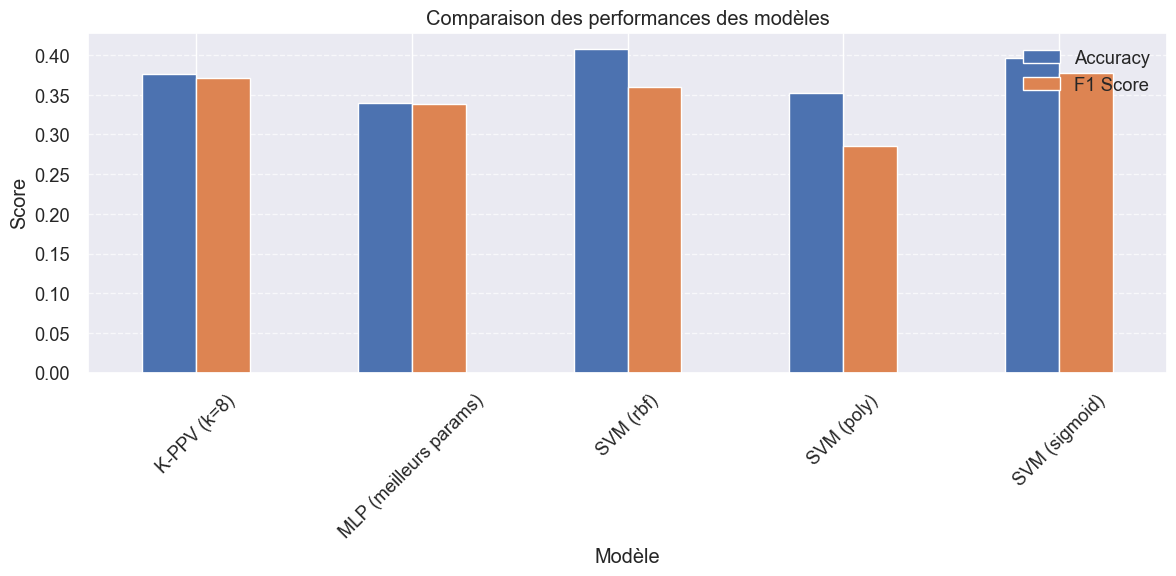

In [22]:
plt.figure(figsize=(12, 6))
comparison_df.set_index('Modèle').plot(kind='bar', figsize=(12, 6))
plt.title('Comparaison des performances des modèles')
plt.ylabel('Score')
plt.xlabel('Modèle')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('model_comparison_client.png')
plt.show()
plt.close()

 Visualiser l'importance des caractéristiques

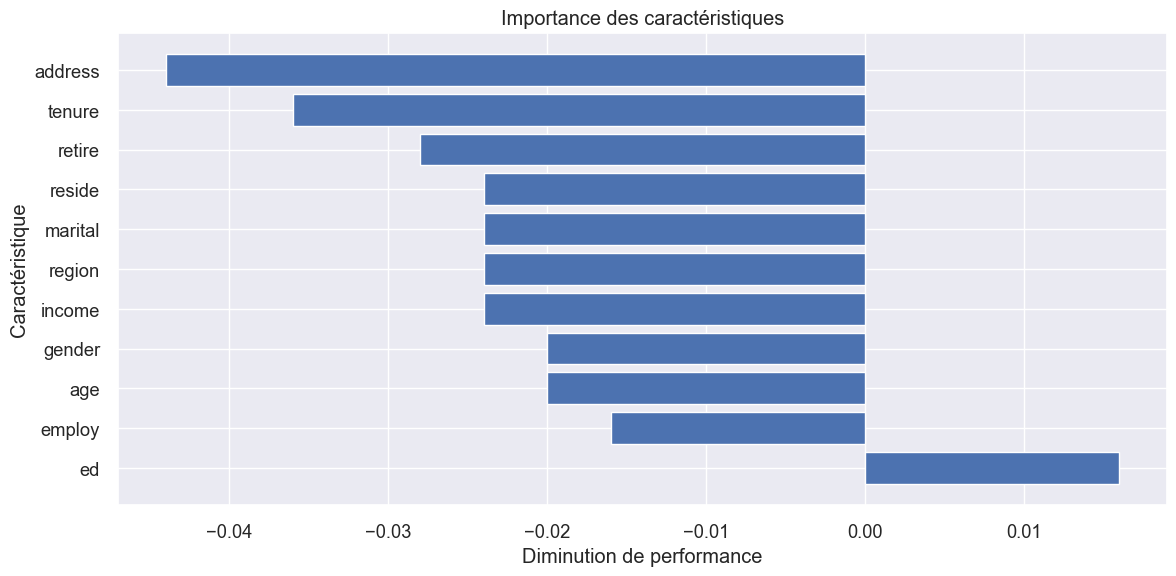

In [23]:
plt.figure(figsize=(12, 6))
features, importances = zip(*feature_importance)
plt.barh(features, importances)
plt.xlabel('Diminution de performance')
plt.ylabel('Caractéristique')
plt.title('Importance des caractéristiques')
plt.tight_layout()
plt.savefig('feature_importance_client.png')
plt.show()
plt.close()